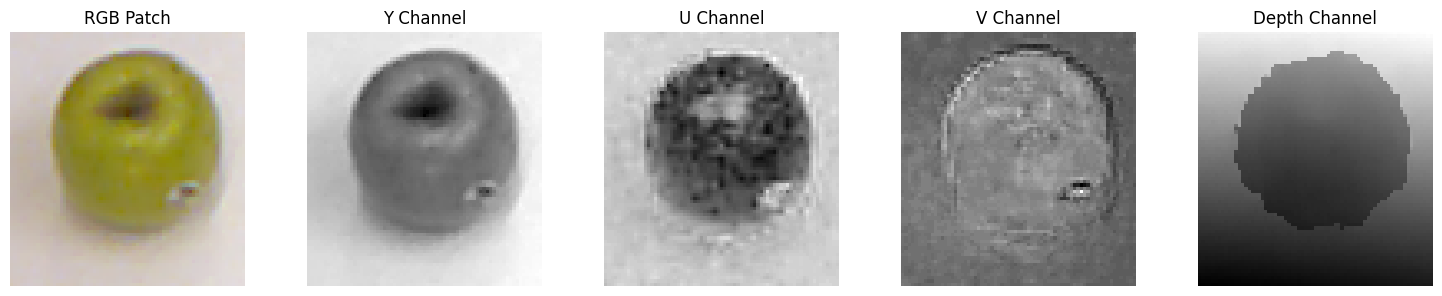

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

rgb_path = r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\archive\08\pcd0820r.png"
depth_path = r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\archive\08\pcd0820d.tiff"
pos_path = r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\archive\08\pcd0820cpos.txt"

rgb_img = np.array(Image.open(rgb_path))
depth_img = np.array(Image.open(depth_path))

with open(pos_path, 'r') as f:
    content = f.readlines()
    
points = []
for j in range(4):
    points.append(list(map(float, content[j].strip().split())))
p = np.array(points)

min_x, max_x = int(np.min(p[:, 0])), int(np.max(p[:, 0]))
min_y, max_y = int(np.min(p[:, 1])), int(np.max(p[:, 1]))

min_x, max_x = max(0, min_x), min(rgb_img.shape[1], max_x)
min_y, max_y = max(0, min_y), min(rgb_img.shape[0], max_y)

rgb_patch = rgb_img[min_y:max_y, min_x:max_x]
depth_patch = depth_img[min_y:max_y, min_x:max_x]

yuv_patch = cv2.cvtColor(rgb_patch, cv2.COLOR_RGB2YUV)

# Key Aspects of YUV:
# Components: Y (Luma/Brightness), U (Blue-difference/Chroma), and V (Red-difference/Chroma).
# Purpose: Developed to allow color transmission in TV while remaining backward compatible with black-and-white sets.
# Advantage: Exploits human visual perception, which is more sensitive to brightness changes than color changes, allowing for high compression.
# YCbCr Relation: In digital video, "YUV" is often used interchangeably with YCbCr, which is the digital encoding format.
# Structure: Often stored in a planar format (all Y, then all U, then all V) rather than interleaved like RGB.

Y_channel = yuv_patch[:, :, 0]
U_channel = yuv_patch[:, :, 1]
V_channel = yuv_patch[:, :, 2]
D_channel = depth_patch

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(rgb_patch)
axes[0].set_title("RGB Patch")
axes[1].imshow(Y_channel, cmap='gray')
axes[1].set_title("Y Channel")
axes[2].imshow(U_channel, cmap='gray')
axes[2].set_title("U Channel")
axes[3].imshow(V_channel, cmap='gray')
axes[3].set_title("V Channel")
axes[4].imshow(D_channel, cmap='gray') 
axes[4].set_title("Depth Channel")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.1 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 0.9/8.1 MB 9.4 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 35.4 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 46.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 42.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/309.1 kB ? eta -:--:--
   --------------------------------------- 309.1/309.1 kB 19.9 MB/s eta 0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


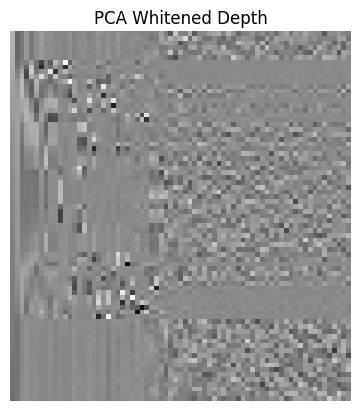

In [ ]:
%pip install scikit-learn


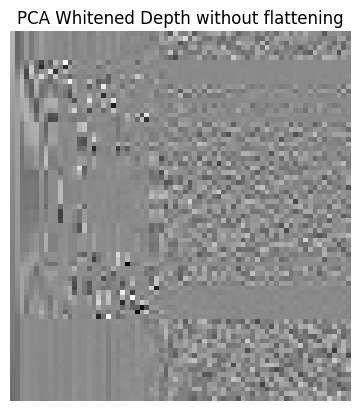

In [36]:
from sklearn.decomposition import PCA

pca = PCA(whiten=True)
depth_whitened = pca.fit_transform(D_channel)

plt.imshow(depth_whitened, cmap='gray')
plt.title("PCA Whitened Depth without flattening")
plt.axis('off')
plt.show()

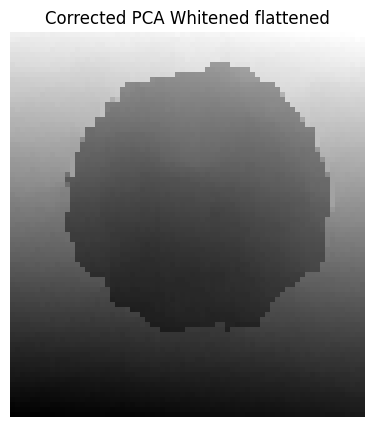

In [38]:
h, w = D_channel.shape
# Flatten to a 1D array of pixels
depth_flat = D_channel.reshape(-1, 1) 

pca = PCA(whiten=True)
# This calculates the bias across the WHOLE patch
depth_whitened_flat = pca.fit_transform(depth_flat)

# Reshape back to the original patch dimensions for visualization
depth_whitened = depth_whitened_flat.reshape(h, w)

plt.figure(figsize=(5, 5))
plt.imshow(depth_whitened, cmap='gray')
plt.title("Corrected PCA Whitened flattened")
plt.axis('off')
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
from sklearn.decomposition import PCA

root_dir = r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\archive"
output_dir = r"C:\Users\park2\Desktop\ME592_HW2\processed_features"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Starting batch processing...")

for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith("r.png"):  # Find RGB images
            base_name = file[:-5]   # Get 'pcd0820' from 'pcd0820r.png'
            
            # Construct paths
            rgb_path = os.path.join(subdir, file)
            depth_path = os.path.join(subdir, base_name + "d.tiff")
            
            # Check if matching depth file exists
            if os.path.exists(depth_path):
                rgb_img = np.array(Image.open(rgb_path))
                depth_img = np.array(Image.open(depth_path))

                # 2. Convert RGB to YUV (Step 3)
                yuv_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2YUV)

                # 3. PCA Whitening on Depth (Step 4)
                h, w = depth_img.shape
                d_flat = depth_img.reshape(-1, 1)
                
                pca = PCA(whiten=True)
                # Flatten -> Transform -> Reshape back to 2D
                depth_whitened = pca.fit_transform(d_flat).reshape(h, w)

                np.save(os.path.join(output_dir, f"{base_name}_yuv.npy"), yuv_img)
                np.save(os.path.join(output_dir, f"{base_name}_whitened_depth.npy"), depth_whitened)

print(f"Done! Features stored in: {output_dir}")

Starting batch processing...
Done! Features stored in: C:\Users\park2\Desktop\ME592_HW2\processed_features


In [35]:
%pip install open3d

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


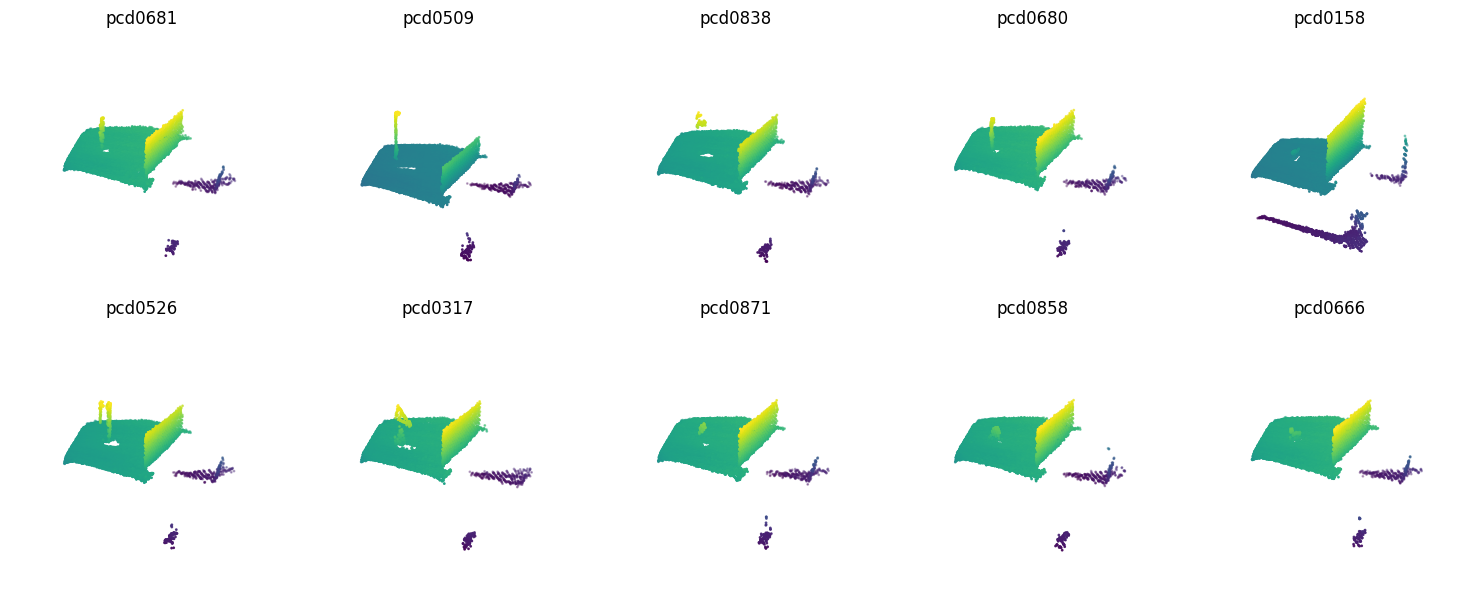

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

root_dir = r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\archive"
pcd_files = []

# 1. Gather ALL the point cloud files first
for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith(".txt") and "cpos" not in file and "cneg" not in file:
            pcd_files.append(os.path.join(subdir, file))

# 2. Pick 10 random files from the massive list
random_10_files = random.sample(pcd_files, 10)

# 3. Plot them
fig = plt.figure(figsize=(15, 6))

for i, file_path in enumerate(random_10_files):
    data = np.loadtxt(file_path, skiprows=11)
# !!!! "sub-sample" by only plotting every 20th point. !!!!!!
    points = data[::20, :3] 
    
    ax = fig.add_subplot(2, 5, i+1, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1, c=points[:, 2], cmap='viridis')
    
    ax.set_title(os.path.basename(file_path)[:-4])
    ax.set_axis_off()

plt.tight_layout()
plt.show()

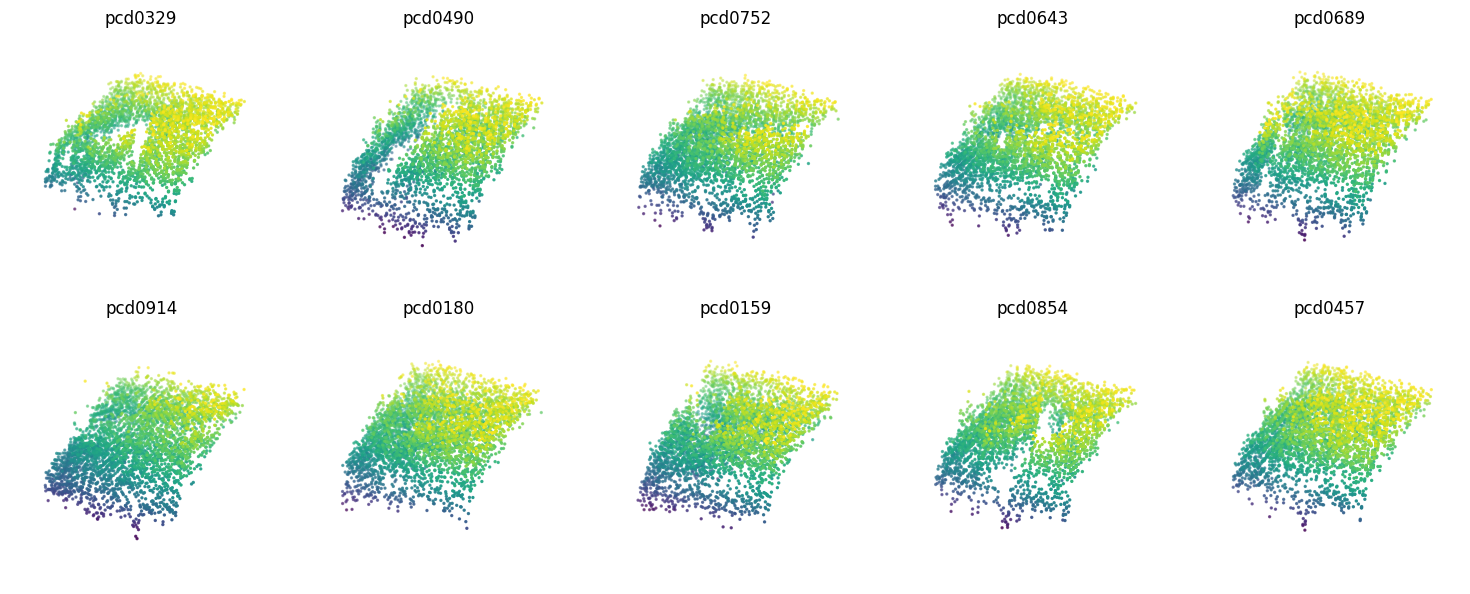

In [46]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

root_dir = r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\archive"
pcd_files = []

for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith(".txt") and "cpos" not in file and "cneg" not in file:
            pcd_files.append(os.path.join(subdir, file))

random_10_files = random.sample(pcd_files, 10)

fig = plt.figure(figsize=(15, 6))

for i, file_path in enumerate(random_10_files):
    data = np.loadtxt(file_path, skiprows=11)
    points = data[:, :3] 
    
    # --- THE ZOOM-IN FILTER just chop off 35% of the outer borders in X and Y ---
    x_min, x_max = np.percentile(points[:, 0], [35, 65])
    y_min, y_max = np.percentile(points[:, 1], [35, 65])
    
    # Let's also chop off the deep background wall (Z depth)
    z_max = np.percentile(points[:, 2], 75) 
    
    # Keep only the points that fall inside our "center crop" box
    mask = (points[:, 0] > x_min) & (points[:, 0] < x_max) & \
           (points[:, 1] > y_min) & (points[:, 1] < y_max) & \
           (points[:, 2] < z_max)
           
    zoomed_points = points[mask]
    
    # downsample 
    zoomed_points = zoomed_points[::5] 
    
    ax = fig.add_subplot(2, 5, i+1, projection='3d')
    ax.scatter(zoomed_points[:, 0], zoomed_points[:, 1], zoomed_points[:, 2], 
               s=2, c=zoomed_points[:, 2], cmap='viridis')
    
    ax.set_title(os.path.basename(file_path)[:-4])
    ax.set_axis_off()

plt.tight_layout()
plt.show()